In [2]:
import numpy as np
from scipy.special import factorial
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from typing import Tuple, Optional

In [ ]:
def k(d):
    d = int(d)
    return d**(d-2)*factorial(np.floor(d/2))*factorial(np.floor((d-1)/2))

def omega_th(N, M, num_flips):
    return (N**(num_flips-1)/k(num_flips)) *(1- 4*((M-0.5*N)/N)**2) **(np.floor((num_flips-1)/2))

def num(q,psi,M):
    if q==1:
        return np.exp(-psi*M)
    else:
        temp = (1-(1-q)*psi*M)
        if temp > 0 :
            return (1-(1-q)*psi*M)**(1/(1-q))
        else:
            return 0

def p(q, psi, M, N, delta):
    domain = np.arange(0,N+1,1)
    Z = 0
    for m in domain:
        Z += omega_th(N, m, delta)*num(q,psi,m)
    return num(q,psi,M)/Z

def neg_loglik(x, M, N, delta):
    q = x[0]
    psi = x[1]
    loglik = 0
    for m in M:
        temp = p(q, psi, m, N, delta)
        if temp == 0:
            loglik += -np.inf
        elif temp > 0:
            loglik += np.log(p(q, psi, m, N, delta))
    return -loglik/len(M)

In [4]:
N = 100
delta = 4
domain = np.arange(0,N+1,1)
pp = []
for m in domain:
    pp.append(p(1.8, 0.9, m, N, delta)* omega_th(N, m, delta))

In [20]:
np.random.seed(68)
M_len = 1000
M_emp = np.random.choice(domain, M_len, p=pp)

In [21]:
trace = []
fixed = (M_emp, 100, 4)
def cb(xk):
    # xk is the current point
    fval = neg_loglik(xk, *fixed)        # current objective
    trace.append((xk.copy(), fval))
    print(f"iter {len(trace):3d}: q = {xk[0]}, psi = {xk[1]} ,  f = {fval:.6g}")

bounds = [(1e-12, None),(None, None)]
res = minimize(neg_loglik, [1.1, 1.4],args=fixed, bounds = bounds,  method='nelder-mead', tol=1e-6, callback = cb,  options={'disp': True})

iter   1: q = 1.1825, psi = 1.2599999999999993 ,  f = 17.3536
iter   2: q = 1.3062500000000004, psi = 1.189999999999999 ,  f = 15.2079
iter   3: q = 1.4231250000000002, psi = 0.8749999999999978 ,  f = 14.3922
iter   4: q = 1.7290625000000004, psi = 0.5774999999999966 ,  f = 14.073
iter   5: q = 1.7290625000000004, psi = 0.5774999999999966 ,  f = 14.073
iter   6: q = 1.7290625000000004, psi = 0.5774999999999966 ,  f = 14.073
iter   7: q = 1.7290625000000004, psi = 0.5774999999999966 ,  f = 14.073
iter   8: q = 1.7290625000000004, psi = 0.5774999999999966 ,  f = 14.073
iter   9: q = 1.7290625000000004, psi = 0.5774999999999966 ,  f = 14.073
iter  10: q = 1.7290625000000004, psi = 0.5774999999999966 ,  f = 14.073
iter  11: q = 1.7290625000000004, psi = 0.5774999999999966 ,  f = 14.073
iter  12: q = 1.7557031250000006, psi = 0.669374999999997 ,  f = 14.0721
iter  13: q = 1.7557031250000006, psi = 0.669374999999997 ,  f = 14.0721
iter  14: q = 1.7770800781250005, psi = 0.8514843749999979 , 

In [22]:
q_star = res.x[0]
psi_star = res.x[1]

In [23]:
p_inferred = []
for m in domain:
    p_inferred.append(p(q_star, psi_star, m, N, delta)* omega_th(N, m, delta))

/tmp/ipykernel_101585/2396664086.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


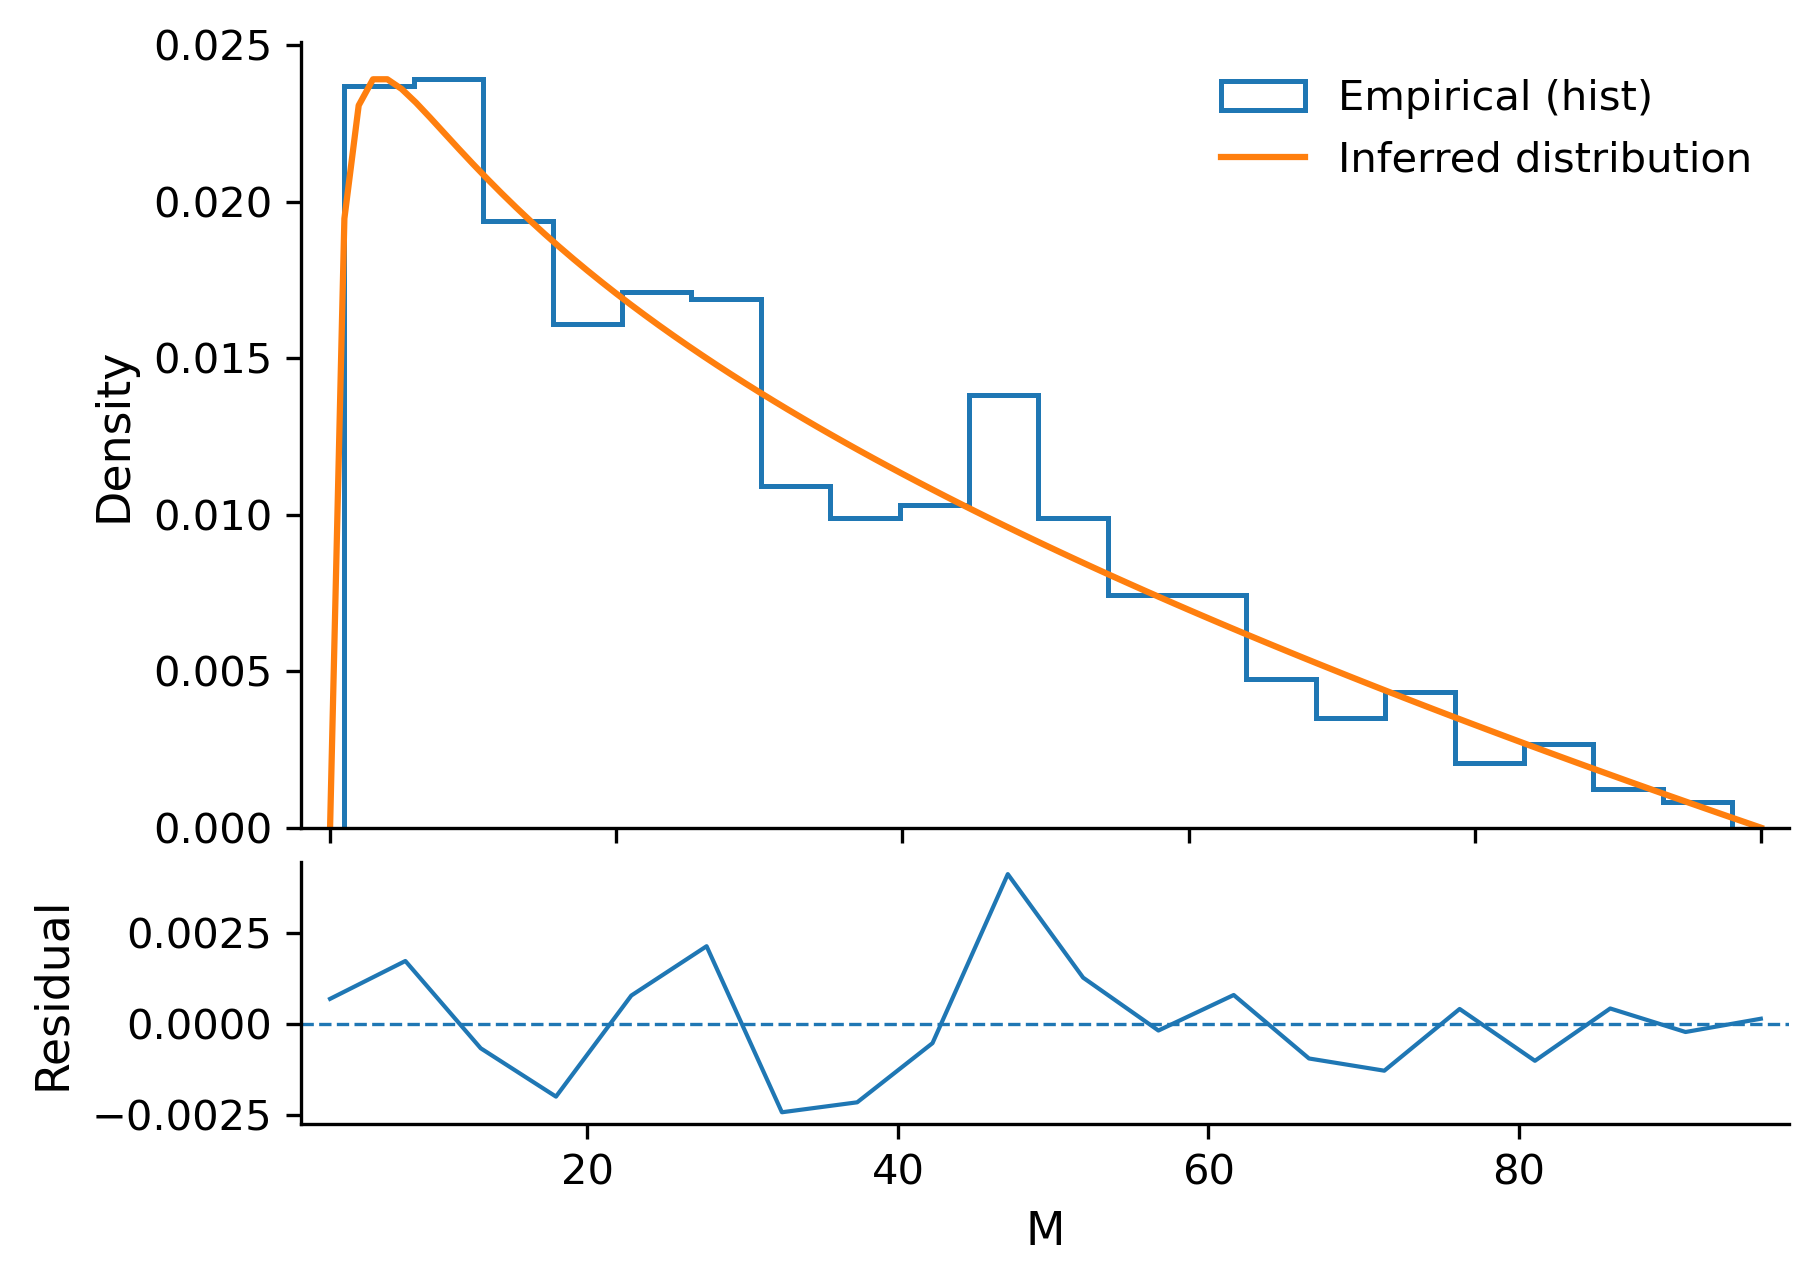

In [24]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "pdf.fonttype": 42, 
    "ps.fonttype": 42,
    "axes.linewidth": 0.8,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.frameon": False,
    "legend.fontsize": 10,
    "axes.spines.right": False,
    "axes.spines.top": False,
})


def fd_bins(x):
    x = np.asarray(x)
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    n = len(x)
    if iqr == 0:
        return min(50, max(10, int(np.sqrt(n))))
    h = 2 * iqr * n ** (-1/3)
    bins = int(np.ceil((x.max() - x.min()) / max(h, np.finfo(float).eps)))
    return np.clip(bins, 20, 120)   # guardrails

bins = fd_bins(M_emp)

# --- Compute histogram and residuals on bin centers --------------------------
hist_vals, bin_edges = np.histogram(M_emp, bins=bins, density=True)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Interpolate model onto bin centers for residuals
pp_on_bins = np.interp(bin_centers, domain, pp)
residuals = hist_vals - pp_on_bins

# --- FIGURE: top density + bottom residuals ---------------------------------
fig = plt.figure()#figsize=(4.6, 4.6)
gs = fig.add_gridspec(nrows=4, ncols=1, hspace=0.05, height_ratios=[3, 0.03, 1, 0.05])

ax = fig.add_subplot(gs[0])
ax_res = fig.add_subplot(gs[2]) 

# Density: step histogram (clean) + model curve
ax.hist(M_emp, bins=bins, density=True, histtype="step", linewidth=1.2, label="Empirical (hist)")
ax.plot(domain, p_inferred, linewidth=1.5, label="Inferred distribution")

# Labels, legend
ax.set_ylabel("Density")
ax.set_xticklabels([])  # handled by residuals axis
ax.legend(loc="upper right", ncols=1)
ax.margins(x=0.02)

# Residuals panel
ax_res.axhline(0, linestyle="--", linewidth=0.8)
ax_res.plot(bin_centers, residuals, linewidth=1.0)
ax_res.set_xlabel("M")
ax_res.set_ylabel("Residual")  # Δ = hist − model
ax_res.margins(x=0.02)

# Tight layout and save (vector)
plt.tight_layout()
plt.savefig("empirical_vs_inferred.pdf")  # or .eps
plt.show()

In [ ]:
xmin, xmax = 1.76, 1.88
ymin, ymax = 0.8, 1.8
n          = 20          # grid resolution

x = np.linspace(xmin, xmax, n)
y = np.linspace(ymin, ymax, n)
X, Y = np.meshgrid(x, y)  # shapes (n, n)

f_vec = np.vectorize(lambda xx, yy: -neg_loglik([xx, yy],M_emp, N, delta), otypes=[float])
Z = f_vec(X, Y)           # same shape as X, Y

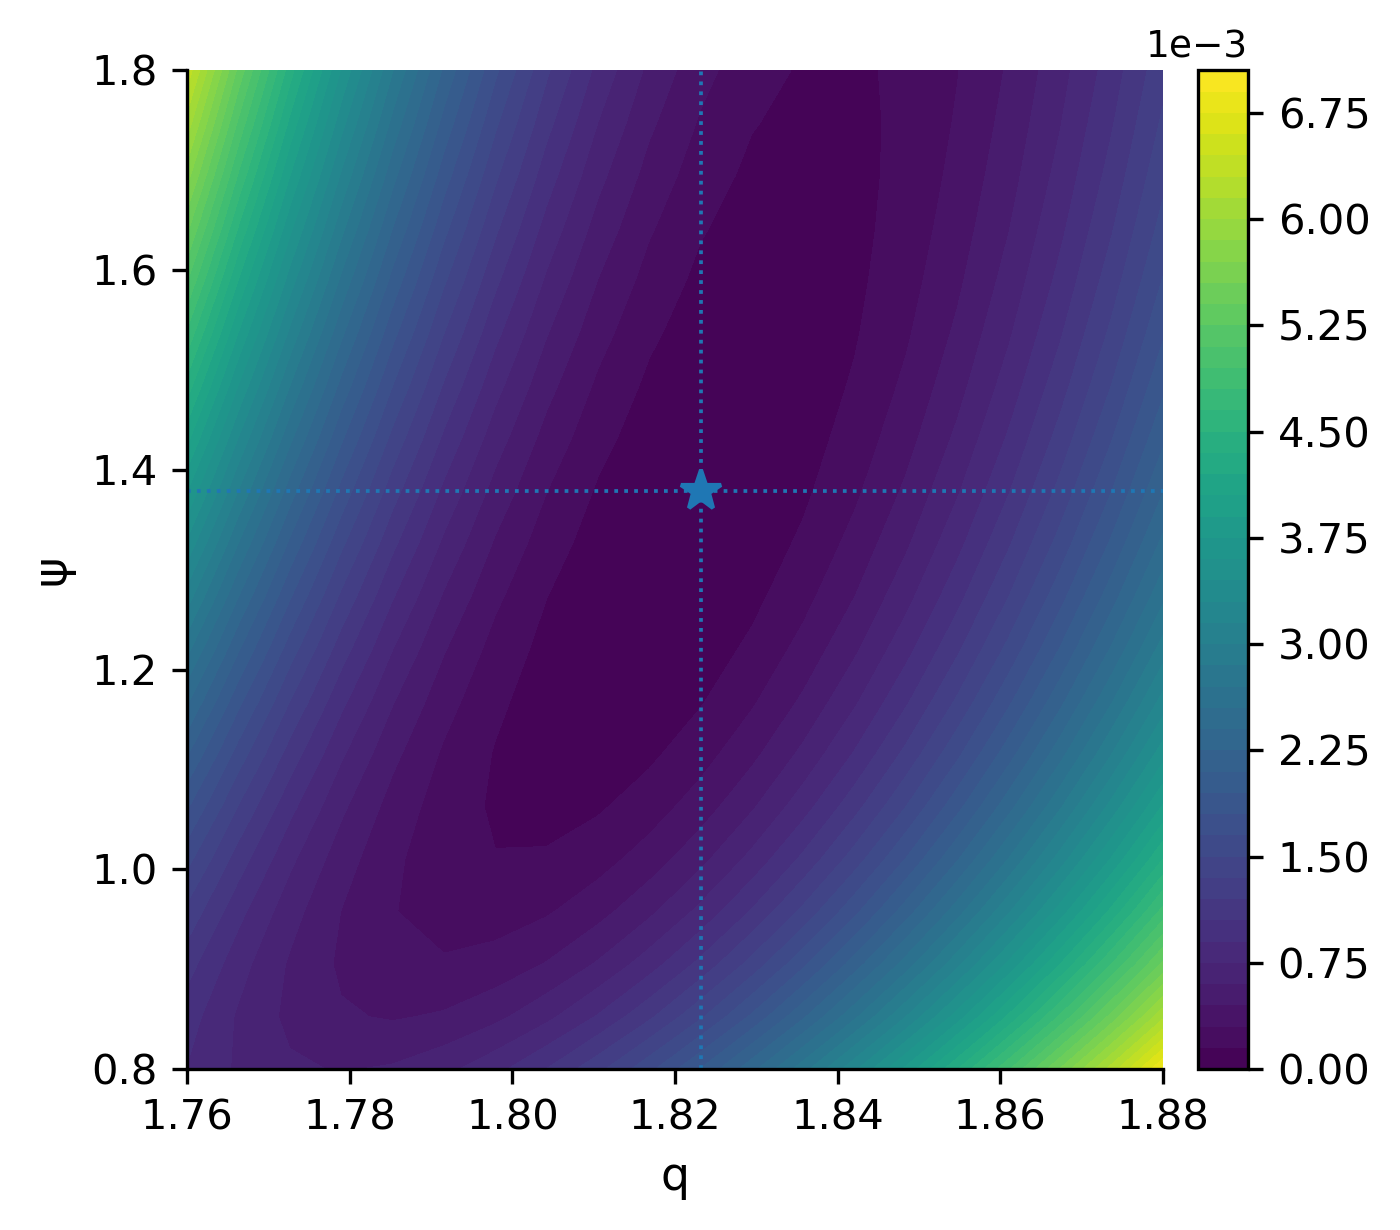

In [ ]:
max_idx = np.unravel_index(np.nanargmax(Z), Z.shape)
q_star = X[max_idx]
psi_star = Y[max_idx]
Zmax = Z[max_idx]
dell = Zmax - Z  

# Confidence levels for 2 parameters (Δℓ)
levels = np.array([1.15, 3.09, 5.92])  # ~68.3%, 95.4%, 99.7%

fig, ax = plt.subplots(figsize=(4.8, 4.2))

# Filled background (soft), isolines at the confidence levels
cf = ax.contourf(X, Y, dell, levels=50)  # many smooth fills
c = ax.contour(X, Y, dell, levels=levels, linewidths=1.2)
ax.clabel(c, fmt={levels[0]:"68%", levels[1]:"95%", levels[2]:"99.7%"}, inline=True, fontsize=9)

# Mark the MLE and add cross-hair
ax.plot(q_star, psi_star, marker="*", markersize=10)
ax.axvline(q_star, linestyle=":", linewidth=0.9)
ax.axhline(psi_star, linestyle=":", linewidth=0.9)

ax.set_xlabel("q")
ax.set_ylabel("ψ")
#ax.set_title("Likelihood landscape (Δℓ from maximum)")
cbar = fig.colorbar(cf, ax=ax, shrink=1, pad=0.03)
cbar.ax.ticklabel_format(style="sci", axis="y", scilimits=(-3,-3))
cbar.ax.yaxis.get_offset_text().set_fontsize(9)
plt.tight_layout()
plt.savefig("likelihood_contours.pdf")
plt.show()